<a href="https://colab.research.google.com/github/Elvinaade/Elvina/blob/main/Dashboard_Prediksi_Saham_LSTM_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Dashboard Prediksi Harga Saham Bank Indonesia
## BCA (BBCA) | BRI (BBRI) | Mandiri (BMRI) | BNI (BBNI)
### Menggunakan Model LSTM (Long Short-Term Memory)

---
**Deskripsi:** Dashboard interaktif berbasis Streamlit untuk memprediksi harga saham empat bank besar Indonesia menggunakan deep learning LSTM berdasarkan data historis dari Yahoo Finance.

**Langkah-langkah:**
1. Install dependensi
2. Jalankan sel kode untuk membuat file `app.py`
3. Jalankan Streamlit


## 📦 1. Install Library yang Dibutuhkan

In [ ]:
# Install semua dependensi yang dibutuhkan
!pip install streamlit yfinance tensorflow scikit-learn pandas numpy matplotlib plotly streamlit-option-menu pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 42.3 MB/s eta 0:00:00


## 🧠 2. Import Library & Konfigurasi

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import datetime

print('✅ Semua library berhasil diimport!')
print(f'📅 Tanggal: {datetime.datetime.now().strftime("%d %B %Y %H:%M")}')

✅ Semua library berhasil diimport!
📅 Tanggal: 25 June 2026 13:28


## 📊 3. Ambil & Eksplorasi Data Historis Saham

In [ ]:
import datetime

# Konfigurasi saham bank Indonesia
SAHAM = {
    'BCA':     {'ticker': 'BBCA.JK', 'warna': '#003d82', 'nama_lengkap': 'Bank Central Asia'},
    'BRI':     {'ticker': 'BBRI.JK', 'warna': '#003580', 'nama_lengkap': 'Bank Rakyat Indonesia'},
    'MANDIRI': {'ticker': 'BMRI.JK', 'warna': '#f7941d', 'nama_lengkap': 'Bank Mandiri'},
    'BNI':     {'ticker': 'BBNI.JK', 'warna': '#f26522', 'nama_lengkap': 'Bank Negara Indonesia'},
}

# Unduh data historis 3 tahun terakhir
END_DATE   = datetime.datetime.today()
START_DATE = END_DATE - datetime.timedelta(days=5*365)

print(f'⬇️  Mengunduh data dari {START_DATE.strftime("%d-%m-%Y")} hingga {END_DATE.strftime("%d-%m-%Y")}...\n')

data_saham = {}
for nama, info in SAHAM.items():
    df = yf.download(info['ticker'], start=START_DATE, end=END_DATE, progress=False)
    df.dropna(inplace=True)
    data_saham[nama] = df
    print(f'✅ {nama} ({info["ticker"]}): {len(df)} baris data | Harga terakhir: Rp {float(df["Close"].iloc[-1]):,.0f}')

print('\n📥 Unduhan data selesai!')

⬇️  Mengunduh data dari 26-06-2021 hingga 25-06-2026...

✅ BCA (BBCA.JK): 1201 baris data | Harga terakhir: Rp 6,025
✅ BRI (BBRI.JK): 1201 baris data | Harga terakhir: Rp 2,850
✅ MANDIRI (BMRI.JK): 1201 baris data | Harga terakhir: Rp 4,000
✅ BNI (BBNI.JK): 1201 baris data | Harga terakhir: Rp 3,350

📥 Unduhan data selesai!


In [ ]:
# Tampilkan statistik deskriptif
for nama, df in data_saham.items():
    info = SAHAM[nama]
    close = df['Close'].squeeze()
    print(f'\n📌 {nama} - {info["nama_lengkap"]} ({info["ticker"]})')
    print(f'   Harga Min  : Rp {close.min():>12,.0f}')
    print(f'   Harga Max  : Rp {close.max():>12,.0f}')
    print(f'   Harga Rata²: Rp {close.mean():>12,.0f}')
    print(f'   Std Dev    : Rp {close.std():>12,.0f}')
    pct = ((close.iloc[-1] - close.iloc[0]) / close.iloc[0]) * 100
    print(f'   Return 5Thn: {pct:>+.2f}%')


📌 BCA - Bank Central Asia (BBCA.JK)
   Harga Min  : Rp        4,850
   Harga Max  : Rp       10,061
   Harga Rata²: Rp        7,654
   Std Dev    : Rp        1,115
   Return 5Thn: +16.13%

📌 BRI - Bank Rakyat Indonesia (BBRI.JK)
   Harga Min  : Rp        2,399
   Harga Max  : Rp        5,217
   Harga Rata²: Rp        3,586
   Std Dev    : Rp          548
   Return 5Thn: +12.14%

📌 MANDIRI - Bank Mandiri (BMRI.JK)
   Harga Min  : Rp        2,006
   Harga Max  : Rp        6,095
   Harga Rata²: Rp        4,044
   Std Dev    : Rp          998
   Return 5Thn: +98.57%

📌 BNI - Bank Negara Indonesia (BBNI.JK)
   Harga Min  : Rp        1,738
   Harga Max  : Rp        5,026
   Harga Rata²: Rp        3,644
   Std Dev    : Rp          669
   Return 5Thn: +92.77%


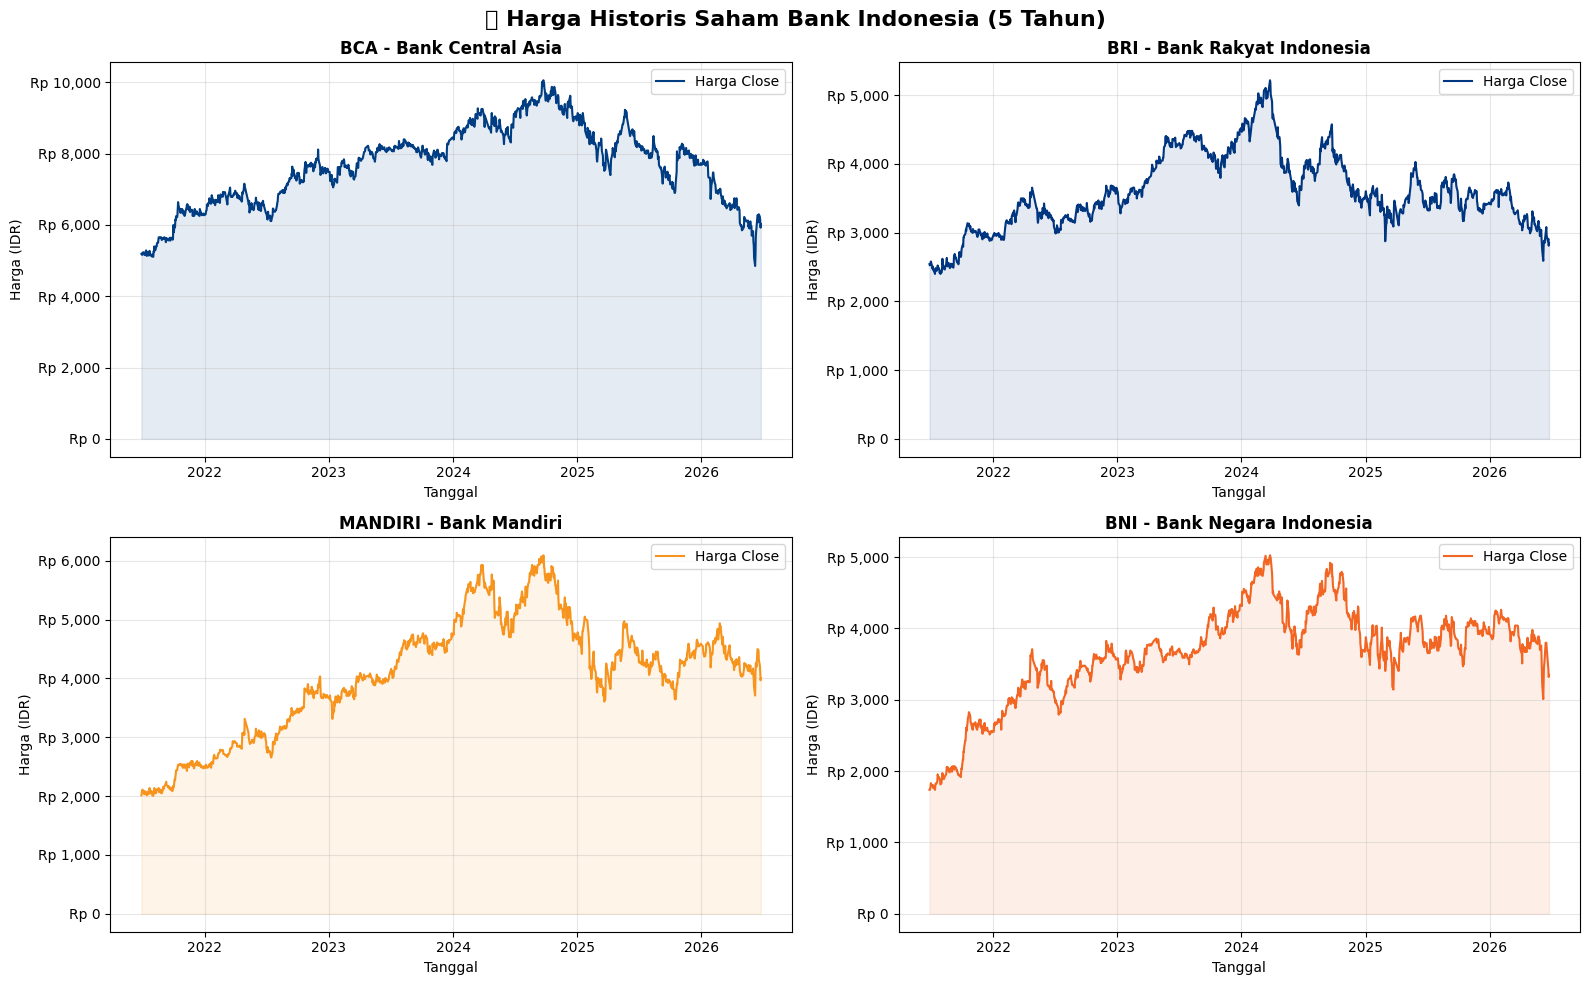

✅ Grafik historis ditampilkan!


In [ ]:
# Visualisasi harga historis semua saham
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📈 Harga Historis Saham Bank Indonesia (5 Tahun)', fontsize=16, fontweight='bold')

for idx, (nama, df) in enumerate(data_saham.items()):
    ax = axes[idx // 2][idx % 2]
    close = df['Close'].squeeze()
    info  = SAHAM[nama]
    ax.plot(df.index, close, color=info['warna'], linewidth=1.5, label='Harga Close')
    ax.fill_between(df.index, close, alpha=0.1, color=info['warna'])
    ax.set_title(f'{nama} - {info["nama_lengkap"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tanggal')
    ax.set_ylabel('Harga (IDR)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('harga_historis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik historis ditampilkan!')

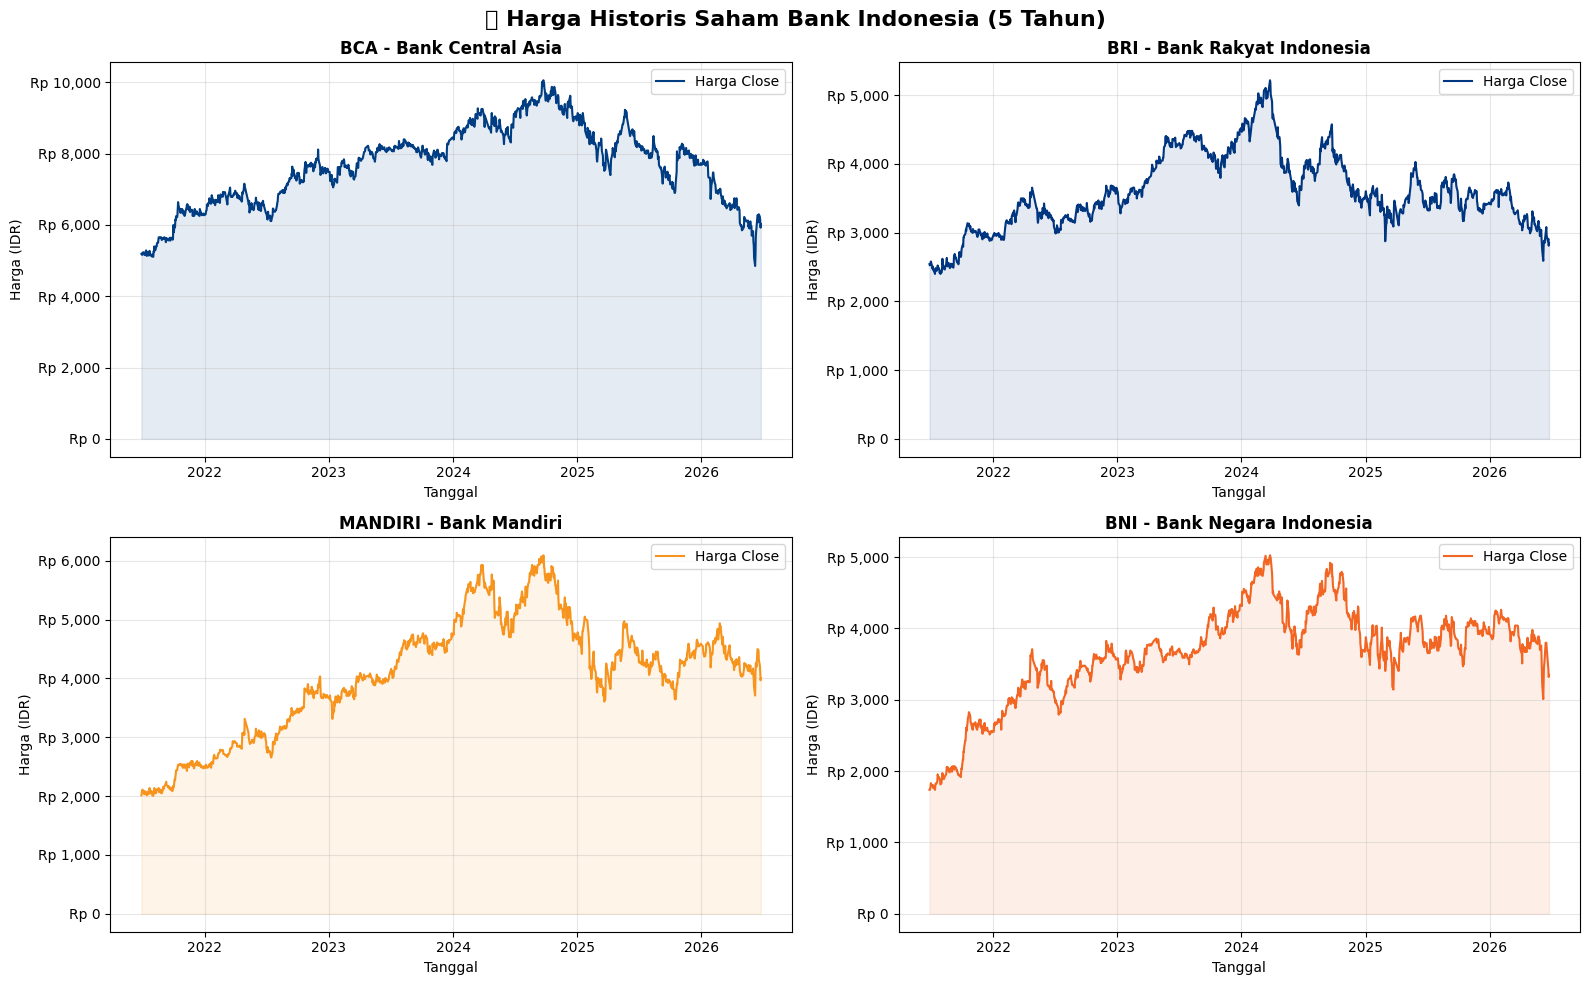

✅ Grafik historis ditampilkan!


In [ ]:
# Visualisasi harga historis semua saham
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📈 Harga Historis Saham Bank Indonesia (5 Tahun)', fontsize=16, fontweight='bold')

for idx, (nama, df) in enumerate(data_saham.items()):
    ax = axes[idx // 2][idx % 2]

    # 🔥 TAMBAHAN: filter mulai tahun 2021
    df = df[df.index >= "2021-01-01"]

    close = df['Close'].squeeze()
    info  = SAHAM[nama]

    ax.plot(df.index, close, color=info['warna'], linewidth=1.5, label='Harga Close')
    ax.fill_between(df.index, close, alpha=0.1, color=info['warna'])

    ax.set_title(f'{nama} - {info["nama_lengkap"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tanggal')
    ax.set_ylabel('Harga (IDR)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('harga_historis.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Grafik historis ditampilkan!')

## 🔧 4. Preprocessing Data & Fungsi LSTM

In [ ]:
def buat_sequences(data, window=60):
    """Membuat sequence data untuk input LSTM."""
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


def bangun_model_lstm(input_shape):
    """Membangun arsitektur model LSTM."""
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        BatchNormalization(),

        LSTM(64, return_sequences=True),
        Dropout(0.2),
        BatchNormalization(),

        LSTM(32, return_sequences=False),
        Dropout(0.2),

        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])
    return model


def latih_dan_prediksi(df, window=60, test_ratio=0.2, epochs=50, batch_size=32):
    """Pipeline lengkap: preprocessing → train → predict → inverse."""
    close_vals = df['Close'].values.reshape(-1, 1)

    # Normalisasi
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(close_vals)

    # Split train/test
    split = int(len(scaled) * (1 - test_ratio))
    train_data = scaled[:split]
    test_data  = scaled[split - window:]

    X_train, y_train = buat_sequences(train_data, window)
    X_test,  y_test  = buat_sequences(test_data,  window)

    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test  = X_test.reshape(X_test.shape[0],   X_test.shape[1],  1)

    # Bangun & latih model
    model = bangun_model_lstm((window, 1))
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=0
    )

    # Prediksi
    pred_scaled = model.predict(X_test, verbose=0)
    pred_actual = scaler.inverse_transform(pred_scaled)
    y_actual    = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Prediksi 30 hari ke depan
    last_seq = scaled[-window:].reshape(1, window, 1)
    future_preds = []
    for _ in range(30):
        next_val = model.predict(last_seq, verbose=0)[0, 0]
        future_preds.append(next_val)
        last_seq = np.roll(last_seq, -1, axis=1)
        last_seq[0, -1, 0] = next_val
    future_actual = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

    # Metrik evaluasi
    mae  = mean_absolute_error(y_actual, pred_actual)
    rmse = np.sqrt(mean_squared_error(y_actual, pred_actual))
    mape = np.mean(np.abs((y_actual - pred_actual) / y_actual)) * 100
    r2   = r2_score(y_actual, pred_actual)

    idx_test = df.index[split:]

    return {
        'model':        model,
        'scaler':       scaler,
        'history':      history.history,
        'y_actual':     y_actual.flatten(),
        'y_pred':       pred_actual.flatten(),
        'idx_test':     idx_test,
        'future_preds': future_actual.flatten(),
        'split':        split,
        'metrics':      {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}
    }

print('✅ Fungsi preprocessing & model LSTM siap!')

✅ Fungsi preprocessing & model LSTM siap!


In [ ]:
# Jumlah missing tiap kolom
print(df.isnull().sum())

# Total missing
print("Total Missing Value:", df.isnull().sum().sum())

# Persentase missing
print((df.isnull().sum() / len(df)) * 100)

Price   Ticker 
Close   BBNI.JK    0
High    BBNI.JK    0
Low     BBNI.JK    0
Open    BBNI.JK    0
Volume  BBNI.JK    0
dtype: int64
Total Missing Value: 0
Price   Ticker 
Close   BBNI.JK    0.0
High    BBNI.JK    0.0
Low     BBNI.JK    0.0
Open    BBNI.JK    0.0
Volume  BBNI.JK    0.0
dtype: float64


In [ ]:
print("Jumlah baris data:", len(df))

Jumlah baris data: 1201


In [ ]:
print("Ukuran data:", df.shape)

Ukuran data: (1201, 5)


In [ ]:
print(df.shape)

(1201, 5)


In [ ]:
print("BCA")
print(data_saham['BCA'].shape)

print("BNI")
print(data_saham['BNI'].shape)

print("Mandiri")
print(data_saham['MANDIRI'].shape)

print("BRI")
print(data_saham['BRI'].shape)

BCA
(1201, 5)
BNI
(1201, 5)
Mandiri
(1201, 5)
BRI
(1201, 5)


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Define df, test_ratio, and scaled for this example
df = data_saham['BCA'] # Menggunakan data BCA sebagai contoh
test_ratio = 0.2

close_vals = df['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(close_vals)

split = int(len(scaled) * (1 - test_ratio))

print(f"Total Data : {len(df)}")
print(f"Train Data : {split}")
print(f"Test Data  : {len(df)-split}")

Total Data : 713
Train Data : 570
Test Data  : 143


## 🚀 5. Training Model LSTM untuk Setiap Saham

In [ ]:
hasil_model = {}

for nama, df in data_saham.items():
    print(f'\n🔄 Melatih model LSTM untuk {nama}...')
    hasil = latih_dan_prediksi(df, window=60, test_ratio=0.2, epochs=100, batch_size=32)
    hasil_model[nama] = hasil
    m = hasil['metrics']
    print(f'   ✅ Selesai | MAE: Rp {m["MAE"]:,.0f} | RMSE: Rp {m["RMSE"]:,.0f} | MAPE: {m["MAPE"]:.2f}% | R²: {m["R2"]:.4f}')

print('\n🎉 Semua model berhasil dilatih!')


🔄 Melatih model LSTM untuk BCA...
   ✅ Selesai | MAE: Rp 510 | RMSE: Rp 589 | MAPE: 7.90% | R²: 0.4421

🔄 Melatih model LSTM untuk BRI...
   ✅ Selesai | MAE: Rp 250 | RMSE: Rp 312 | MAPE: 8.03% | R²: -0.6695

🔄 Melatih model LSTM untuk MANDIRI...
   ✅ Selesai | MAE: Rp 370 | RMSE: Rp 413 | MAPE: 8.25% | R²: -2.6826

🔄 Melatih model LSTM untuk BNI...
   ✅ Selesai | MAE: Rp 102 | RMSE: Rp 157 | MAPE: 2.72% | R²: 0.4543

🎉 Semua model berhasil dilatih!


## 📉 6. Visualisasi Hasil Prediksi vs Aktual

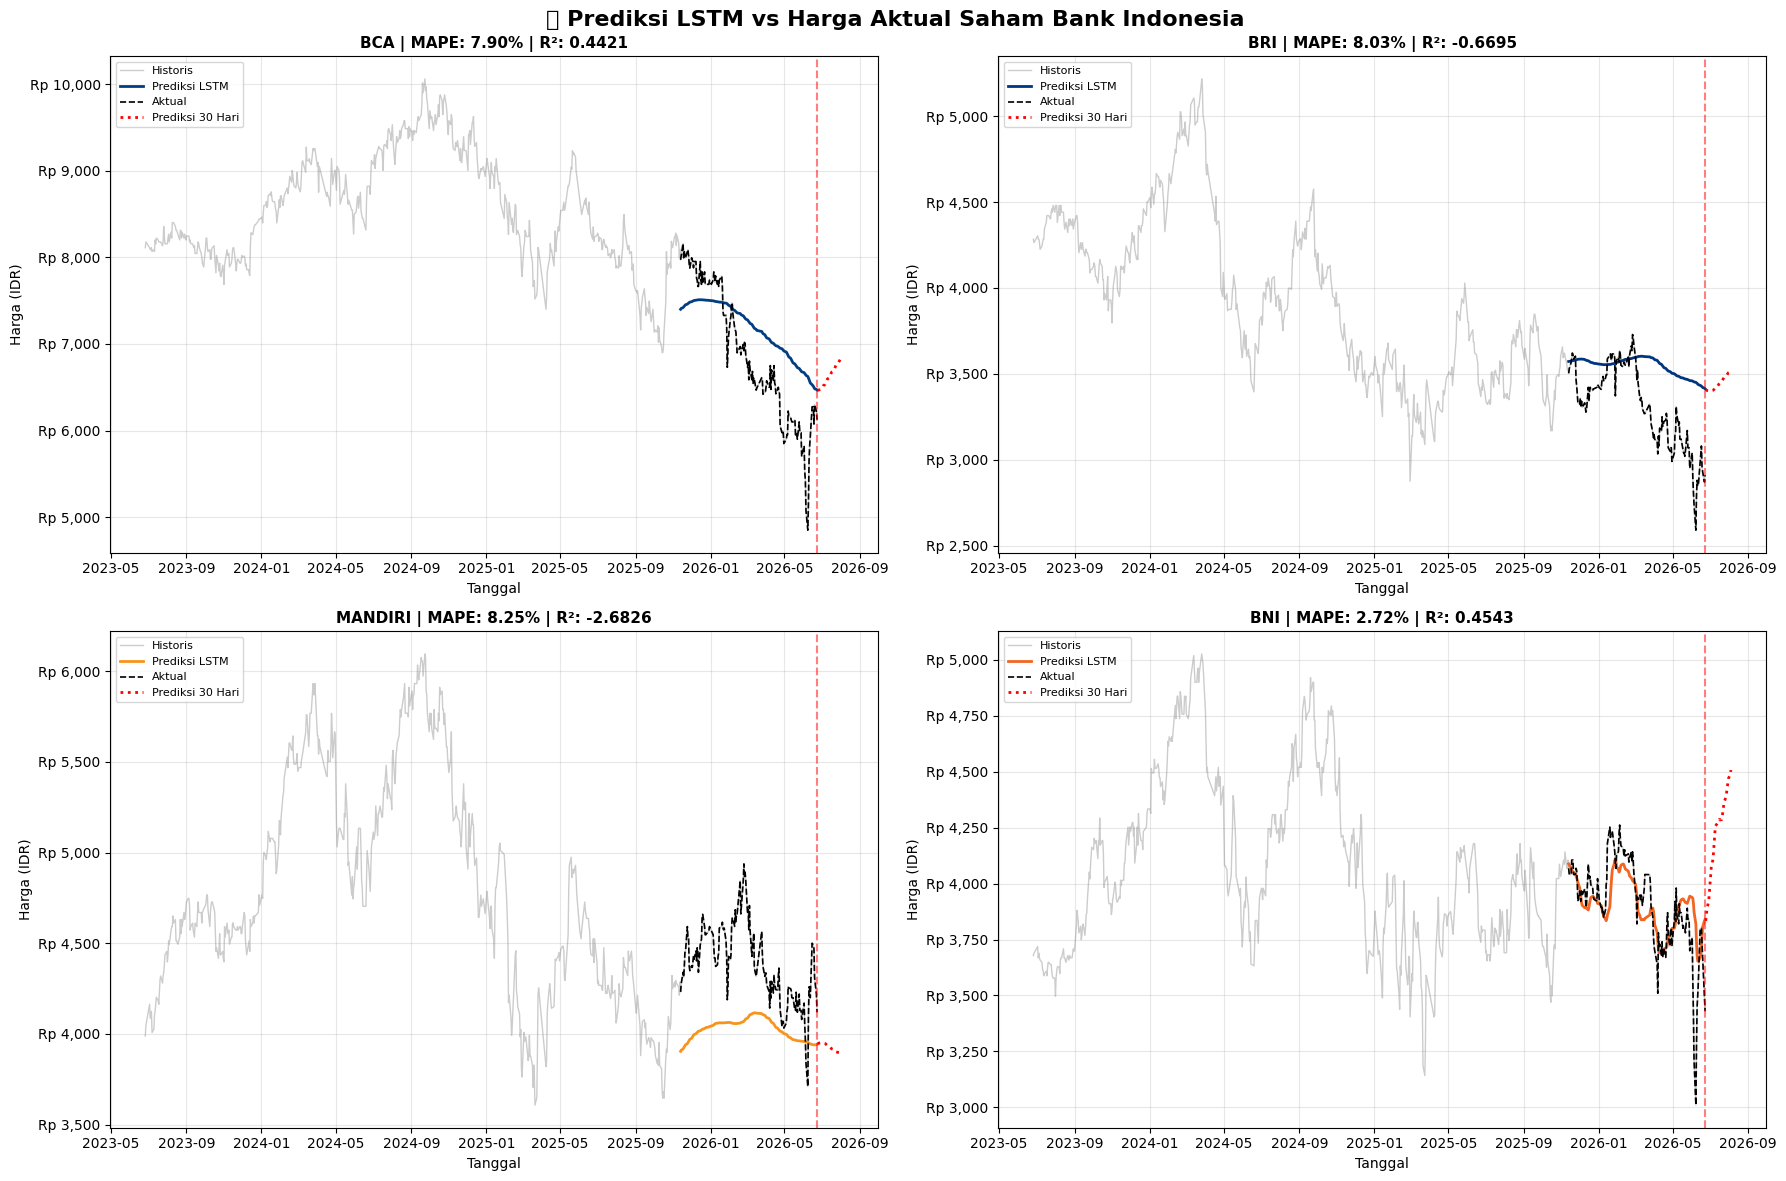

✅ Visualisasi prediksi ditampilkan!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('🤖 Prediksi LSTM vs Harga Aktual Saham Bank Indonesia', fontsize=16, fontweight='bold')

for idx, (nama, hasil) in enumerate(hasil_model.items()):
    ax   = axes[idx // 2][idx % 2]
    info = SAHAM[nama]
    df   = data_saham[nama]

    # Data aktual penuh
    ax.plot(df.index, df['Close'].squeeze(), color='gray', alpha=0.4, linewidth=1, label='Historis')
    # Prediksi test set
    ax.plot(hasil['idx_test'], hasil['y_pred'], color=info['warna'], linewidth=2, label='Prediksi LSTM')
    ax.plot(hasil['idx_test'], hasil['y_actual'], color='black', linewidth=1.2, linestyle='--', label='Aktual')

    # Prediksi 30 hari ke depan
    future_dates = pd.bdate_range(start=df.index[-1], periods=31)[1:]
    ax.plot(future_dates, hasil['future_preds'], color='red', linewidth=2, linestyle=':', label='Prediksi 30 Hari')
    ax.axvline(x=df.index[-1], color='red', linestyle='--', alpha=0.5)

    m = hasil['metrics']
    ax.set_title(f'{nama} | MAPE: {m["MAPE"]:.2f}% | R²: {m["R2"]:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Tanggal')
    ax.set_ylabel('Harga (IDR)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediksi_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi prediksi ditampilkan!')

## 📋 7. Tabel Ringkasan Metrik Evaluasi

In [ ]:
print('\n' + '='*70)
print(f'{'Bank':<10} {'MAE (Rp)':>14} {'RMSE (Rp)':>14} {'MAPE (%)':>10} {'R²':>8}')
print('='*70)
for nama, hasil in hasil_model.items():
    m = hasil['metrics']
    print(f'{nama:<10} {m["MAE"]:>14,.0f} {m["RMSE"]:>14,.0f} {m["MAPE"]:>9.2f}% {m["R2"]:>8.4f}')
print('='*70)

# Tampilkan prediksi 30 hari ke depan
print('\n📅 PREDIKSI HARGA 30 HARI KE DEPAN:')
print('='*70)
for nama, hasil in hasil_model.items():
    fp = hasil['future_preds']
    current = data_saham[nama]['Close'].iloc[-1]
    pct_change = ((fp[-1] - float(current)) / float(current)) * 100
    trend = '📈' if pct_change > 0 else '📉'
    print(f'{trend} {nama:<10} | Saat ini: Rp {float(current):>9,.0f} | 30 Hari: Rp {fp[-1]:>9,.0f} | Perubahan: {pct_change:>+.2f}%')
print('='*70)


Bank             MAE (Rp)      RMSE (Rp)   MAPE (%)       R²
BCA                   510            589      7.90%   0.4421
BRI                   250            312      8.03%  -0.6695
MANDIRI               370            413      8.25%  -2.6826
BNI                   102            157      2.72%   0.4543

📅 PREDIKSI HARGA 30 HARI KE DEPAN:
📈 BCA        | Saat ini: Rp     6,125 | 30 Hari: Rp     6,852 | Perubahan: +11.87%
📈 BRI        | Saat ini: Rp     2,910 | 30 Hari: Rp     3,516 | Perubahan: +20.82%
📉 MANDIRI    | Saat ini: Rp     4,120 | 30 Hari: Rp     3,894 | Perubahan: -5.48%
📈 BNI        | Saat ini: Rp     3,430 | 30 Hari: Rp     4,507 | Perubahan: +31.40%


## 🌐 8. Buat File Aplikasi Streamlit (app.py)

In [ ]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import datetime
import warnings
warnings.filterwarnings("ignore")

# ─── Konfigurasi Halaman ────────────────────────────────────────────────────
st.set_page_config(
    page_title="Dashboard Prediksi Saham Bank",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ─── Styling CSS ─────────────────────────────────────────────────────────────
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem; font-weight: 800; text-align: center;
        background: linear-gradient(135deg, #003d82, #f7941d);
        -webkit-background-clip: text; -webkit-text-fill-color: transparent;
        margin-bottom: 0.5rem;
    }
    .sub-header { text-align: center; color: #666; font-size: 1rem; margin-bottom: 2rem; }
    .metric-card {
        background: linear-gradient(135deg, #f8f9fa, #e9ecef);
        padding: 1rem 1.5rem; border-radius: 12px;
        border-left: 4px solid #003d82; margin: 0.5rem 0;
    }
    .metric-value { font-size: 1.4rem; font-weight: 700; color: #003d82; }
    .metric-label { font-size: 0.8rem; color: #666; }
    .stProgress .st-bo { background-color: #003d82; }
</style>
""", unsafe_allow_html=True)

# ─── Konstanta ───────────────────────────────────────────────────────────────
SAHAM = {
    "BCA":     {"ticker": "BBCA.JK", "warna": "#003d82", "nama": "Bank Central Asia"},
    "BRI":     {"ticker": "BBRI.JK", "warna": "#003580", "nama": "Bank Rakyat Indonesia"},
    "MANDIRI": {"ticker": "BMRI.JK", "warna": "#f7941d", "nama": "Bank Mandiri"},
    "BNI":     {"ticker": "BBNI.JK", "warna": "#f26522", "nama": "Bank Negara Indonesia"},
}

# ─── Fungsi Utama ─────────────────────────────────────────────────────────────
@st.cache_data(ttl=3600)
def ambil_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, progress=False)
    df.dropna(inplace=True)
    return df

def buat_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

def bangun_lstm(input_shape, units_1, units_2, dropout_rate):
    model = Sequential([
        LSTM(units_1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(units_2, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(units_2 // 2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
    return model

@st.cache_resource
def latih_model(ticker, start, end, window, test_ratio, epochs, batch_size, units_1, units_2, dropout):
    df = ambil_data(ticker, start, end)
    close = df["Close"].values.reshape(-1, 1)
    scaler = MinMaxScaler((0, 1))
    scaled = scaler.fit_transform(close)

    split = int(len(scaled) * (1 - test_ratio))
    X_train, y_train = buat_sequences(scaled[:split], window)
    X_test,  y_test  = buat_sequences(scaled[split-window:], window)

    X_train = X_train.reshape(*X_train.shape, 1)
    X_test  = X_test.reshape(*X_test.shape, 1)

    model = bangun_lstm((window, 1), units_1, units_2, dropout)
    cb = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    ]
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_split=0.1, callbacks=cb, verbose=0)

    pred = scaler.inverse_transform(model.predict(X_test, verbose=0))
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Prediksi masa depan
    last_seq = scaled[-window:].reshape(1, window, 1)
    future = []
    for _ in range(30):
        nxt = model.predict(last_seq, verbose=0)[0, 0]
        future.append(nxt)
        last_seq = np.roll(last_seq, -1, axis=1)
        last_seq[0, -1, 0] = nxt
    future_vals = scaler.inverse_transform(np.array(future).reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    r2   = r2_score(actual, pred)

    return {
        "df": df, "scaler": scaler, "history": history.history,
        "actual": actual.flatten(), "pred": pred.flatten(),
        "idx_test": df.index[split:], "future": future_vals, "split": split,
        "metrics": {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}
    }

# ─── Sidebar ─────────────────────────────────────────────────────────────────
with st.sidebar:
    st.image("https://upload.wikimedia.org/wikipedia/commons/thumb/4/40/IDX_logo.svg/200px-IDX_logo.svg.png", width=120)
    st.markdown("## ⚙️ Pengaturan Model")

    bank_dipilih = st.selectbox("🏦 Pilih Bank", list(SAHAM.keys()),
                                 format_func=lambda x: f"{x} - {SAHAM[x]['nama']}")

    st.markdown("### 📅 Periode Data")
    col1, col2 = st.columns(2)
    end_date   = datetime.datetime.today()
    start_date = col1.date_input("Mulai", end_date - datetime.timedelta(days=5*365))
    end_date   = col2.date_input("Akhir", end_date)

    st.markdown("### 🧠 Parameter LSTM")
    window      = st.slider("Window Size",    20, 120, 60, 5)
    epochs      = st.slider("Epochs",         20, 200, 50, 10)
    batch_size  = st.select_slider("Batch Size", [8, 16, 32, 64, 128], 32)
    units_1     = st.slider("LSTM Units Layer 1", 32, 256, 128, 32)
    units_2     = st.slider("LSTM Units Layer 2", 16, 128,  64, 16)
    dropout     = st.slider("Dropout Rate",  0.1, 0.5, 0.2, 0.05)
    test_ratio  = st.slider("Rasio Test (%)",  10,  40,  20,  5) / 100

    train_btn = st.button("🚀 Latih Model", use_container_width=True, type="primary")
    st.markdown("---")
    compare_all = st.button("🔄 Bandingkan Semua Bank", use_container_width=True)

# ─── Header Utama ─────────────────────────────────────────────────────────────
st.markdown('<h1 class="main-header">📈 Dashboard Prediksi Harga Saham Bank Indonesia</h1>', unsafe_allow_html=True)
st.markdown('<p class="sub-header">Model Deep Learning LSTM | BCA · BRI · Mandiri · BNI | Data Real-time Yahoo Finance</p>', unsafe_allow_html=True)
st.markdown("---")

# ─── Tampilkan Harga Terkini Semua Bank ──────────────────────────────────────
st.markdown("### 💹 Harga Penutupan Terkini")
cols = st.columns(4)
for i, (nm, info) in enumerate(SAHAM.items()):
    try:
        df_temp = yf.download(info["ticker"], period="5d", progress=False)
        harga_kini = float(df_temp["Close"].iloc[-1])
        harga_kemarin = float(df_temp["Close"].iloc[-2])
        delta = harga_kini - harga_kemarin
        pct   = (delta / harga_kemarin) * 100
        cols[i].metric(f"🏦 {nm}", f"Rp {harga_kini:,.0f}", f"{pct:+.2f}% ({delta:+,.0f})")
    except:
        cols[i].metric(f"🏦 {nm}", "N/A", "")

st.markdown("---")

# ─── Tab Utama ───────────────────────────────────────────────────────────────
tab1, tab2, tab3, tab4, tab5 = st.tabs([
    "📊 Analisis Historis",
    "🤖 Prediksi LSTM",
    "📉 Evaluasi Model",
    "🔮 Forecast 30 Hari",
    "⚖️ Perbandingan Bank"
])

# ── TAB 1: Analisis Historis ──────────────────────────────────────────────────
with tab1:
    st.subheader(f"📊 Data Historis Saham {bank_dipilih}")
    info = SAHAM[bank_dipilih]
    df_hist = ambil_data(info["ticker"], start_date, end_date)

    if df_hist.empty:
        st.error("❌ Data tidak ditemukan. Periksa koneksi internet.")
    else:
        close_s = df_hist["Close"].squeeze()
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("📈 Harga Tertinggi",  f"Rp {close_s.max():,.0f}")
        c2.metric("📉 Harga Terendah",   f"Rp {close_s.min():,.0f}")
        c3.metric("📊 Rata-rata",         f"Rp {close_s.mean():,.0f}")
        ret5 = ((close_s.iloc[-1] - close_s.iloc[0]) / close_s.iloc[0]) * 100
        c4.metric("💰 Return",            f"{ret5:+.2f}%")

        # Candlestick chart
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                            row_heights=[0.7, 0.3], vertical_spacing=0.05)
        fig.add_trace(go.Candlestick(
            x=df_hist.index,
            open=df_hist["Open"].squeeze(), high=df_hist["High"].squeeze(),
            low=df_hist["Low"].squeeze(),   close=df_hist["Close"].squeeze(),
            name="OHLC", increasing_line_color="#26a69a", decreasing_line_color="#ef5350"
        ), row=1, col=1)
        fig.add_trace(go.Bar(
            x=df_hist.index, y=df_hist["Volume"].squeeze(),
            name="Volume", marker_color=info["warna"], opacity=0.6
        ), row=2, col=1)

        # Moving averages
        for ma, clr in [(20, "orange"), (50, "blue"), (200, "red")]:
            if len(close_s) > ma:
                fig.add_trace(go.Scatter(
                    x=df_hist.index, y=close_s.rolling(ma).mean(),
                    name=f"MA{ma}", line=dict(color=clr, width=1.5, dash="dot")
                ), row=1, col=1)

        fig.update_layout(
            title=f"{bank_dipilih} - {info['nama']} ({info['ticker']})",
            height=600, showlegend=True, xaxis_rangeslider_visible=False
        )
        st.plotly_chart(fig, use_container_width=True)

        with st.expander("📋 Lihat Data Mentah"):
            st.dataframe(df_hist.tail(100).sort_index(ascending=False), use_container_width=True)

        # ── Boxplot harga bulanan ──────────────────────────────────────────────
        st.markdown("**📦 Distribusi Harga Bulanan (Boxplot)**")
        df_box = df_hist.copy()
        df_box["Bulan"] = df_box.index.to_series().dt.to_period("M").astype(str)
        close_vals = df_box["Close"].squeeze()
        df_box["Close_val"] = close_vals.values
        # Ambil 12 bulan terakhir
        bulan_unik = df_box["Bulan"].unique()[-12:]
        df_box12 = df_box[df_box["Bulan"].isin(bulan_unik)]
        fig_box = go.Figure()
        for bln in bulan_unik:
            vals = df_box12[df_box12["Bulan"] == bln]["Close_val"].values
            fig_box.add_trace(go.Box(y=vals, name=bln, marker_color=info["warna"], showlegend=False))
        fig_box.update_layout(
            title=f"Distribusi Harga Bulanan {bank_dipilih} (12 Bulan Terakhir)",
            yaxis_title="Harga (IDR)", xaxis_title="Bulan",
            height=400, yaxis_tickformat=",.0f"
        )
        st.plotly_chart(fig_box, use_container_width=True)

        # ── Bar chart return bulanan ───────────────────────────────────────────
        st.markdown("**📊 Return Bulanan (%)**")
        monthly_close = close_s.resample("M").last()
        monthly_return = monthly_close.pct_change() * 100
        monthly_return = monthly_return.dropna().tail(24)
        colors = [info["warna"] if v >= 0 else "#ef5350" for v in monthly_return.values]
        fig_bar = go.Figure(go.Bar(
            x=monthly_return.index.strftime("%b %Y"),
            y=monthly_return.values,
            marker_color=colors,
            text=[f"{v:+.1f}%" for v in monthly_return.values],
            textposition="outside"
        ))
        fig_bar.add_hline(y=0, line_color="gray", line_dash="dash")
        fig_bar.update_layout(
            title=f"Return Bulanan {bank_dipilih} (2 Tahun Terakhir)",
            xaxis_title="Bulan", yaxis_title="Return (%)",
            height=400, xaxis_tickangle=-45
        )
        st.plotly_chart(fig_bar, use_container_width=True)

        # ── Rolling Volatility ─────────────────────────────────────────────────
        st.markdown("**📉 Volatilitas Bergulir 30 Hari**")
        rolling_vol = close_s.pct_change().rolling(30).std() * (252 ** 0.5) * 100
        fig_vol = go.Figure()
        fig_vol.add_trace(go.Scatter(
            x=rolling_vol.index, y=rolling_vol.values,
            fill="tozeroy", name="Volatilitas Annualized",
            line=dict(color=info["warna"], width=1.5),
            fillcolor=f"rgba(0,61,130,0.15)"
        ))
        fig_vol.update_layout(
            title=f"Volatilitas Bergulir 30 Hari {bank_dipilih}",
            xaxis_title="Tanggal", yaxis_title="Volatilitas Annualized (%)",
            height=350
        )
        st.plotly_chart(fig_vol, use_container_width=True)

# ── TAB 2: Prediksi LSTM ──────────────────────────────────────────────────────
with tab2:
    st.subheader(f"🤖 Prediksi LSTM untuk {bank_dipilih}")
    if train_btn or "hasil" not in st.session_state:
        info = SAHAM[bank_dipilih]
        with st.spinner(f"⏳ Melatih model LSTM untuk {bank_dipilih}... (bisa 1-3 menit)"):
            progress = st.progress(0, text="Mempersiapkan data...")
            hasil = latih_model(
                info["ticker"], start_date, end_date,
                window, test_ratio, epochs, batch_size,
                units_1, units_2, dropout
            )
            progress.progress(100, text="✅ Selesai!")
            st.session_state["hasil"] = hasil
            st.session_state["bank_aktif"] = bank_dipilih
        st.success(f"✅ Model {bank_dipilih} berhasil dilatih!")

    if "hasil" in st.session_state:
        hasil = st.session_state["hasil"]
        bank_aktif = st.session_state.get("bank_aktif", bank_dipilih)
        info = SAHAM[bank_aktif]
        df_r = hasil["df"]

        fig = go.Figure()
        close_full = df_r["Close"].squeeze()
        fig.add_trace(go.Scatter(x=df_r.index, y=close_full, name="Historis",
                                  line=dict(color="lightgray", width=1)))
        fig.add_trace(go.Scatter(x=hasil["idx_test"], y=hasil["actual"], name="Aktual",
                                  line=dict(color="black", width=2)))
        fig.add_trace(go.Scatter(x=hasil["idx_test"], y=hasil["pred"], name="Prediksi LSTM",
                                  line=dict(color=info["warna"], width=2.5)))
        future_dates = pd.bdate_range(start=df_r.index[-1], periods=31)[1:]
        fig.add_trace(go.Scatter(x=future_dates, y=hasil["future"], name="Forecast 30 Hari",
                                  line=dict(color="red", width=2, dash="dot")))
        fig.add_vline(x=df_r.index[-1], line_dash="dash", line_color="red", opacity=0.5)

        m = hasil["metrics"]
        fig.update_layout(
            title=f"{bank_aktif} | MAE: Rp {m['MAE']:,.0f} | MAPE: {m['MAPE']:.2f}% | R²: {m['R2']:.4f}",
            xaxis_title="Tanggal", yaxis_title="Harga (IDR)",
            height=500, hovermode="x unified"
        )
        st.plotly_chart(fig, use_container_width=True)
    else:
        st.info("👆 Klik tombol **Latih Model** di sidebar untuk memulai prediksi.")

# ── TAB 3: Evaluasi Model ─────────────────────────────────────────────────────
with tab3:
    st.subheader("📉 Evaluasi Performa Model LSTM")
    if "hasil" in st.session_state:
        hasil = st.session_state["hasil"]
        m = hasil["metrics"]
        bank_aktif = st.session_state.get("bank_aktif", bank_dipilih)

        # Metrik kartu
        c1, c2, c3, c4 = st.columns(4)
        c1.metric("MAE",  f"Rp {m['MAE']:,.0f}",  help="Mean Absolute Error")
        c2.metric("RMSE", f"Rp {m['RMSE']:,.0f}", help="Root Mean Square Error")
        c3.metric("MAPE", f"{m['MAPE']:.2f}%",    help="Mean Absolute Percentage Error")
        c4.metric("R²",   f"{m['R2']:.4f}",        help="Koefisien Determinasi")

        col_l, col_r = st.columns(2)

        # Loss curve
        with col_l:
            st.markdown("**📈 Kurva Loss Training**")
            fig_loss = go.Figure()
            fig_loss.add_trace(go.Scatter(y=hasil["history"]["loss"],     name="Train Loss", line=dict(color="blue")))
            fig_loss.add_trace(go.Scatter(y=hasil["history"]["val_loss"], name="Val Loss",   line=dict(color="red")))
            fig_loss.update_layout(xaxis_title="Epoch", yaxis_title="MSE Loss", height=350)
            st.plotly_chart(fig_loss, use_container_width=True)

        # Scatter aktual vs prediksi
        with col_r:
            st.markdown("**🎯 Aktual vs Prediksi**")
            fig_sc = go.Figure()
            fig_sc.add_trace(go.Scatter(
                x=hasil["actual"], y=hasil["pred"], mode="markers",
                marker=dict(color=SAHAM[bank_aktif]["warna"], opacity=0.5, size=4),
                name="Pred vs Actual"
            ))
            mn = min(hasil["actual"].min(), hasil["pred"].min())
            mx = max(hasil["actual"].max(), hasil["pred"].max())
            fig_sc.add_trace(go.Scatter(x=[mn, mx], y=[mn, mx], mode="lines",
                                         name="Ideal", line=dict(color="red", dash="dash")))
            fig_sc.update_layout(xaxis_title="Aktual (Rp)", yaxis_title="Prediksi (Rp)", height=350)
            st.plotly_chart(fig_sc, use_container_width=True)

        # Residuals
        residuals = hasil["actual"] - hasil["pred"]
        st.markdown("**📊 Distribusi Residual Error**")
        fig_res = px.histogram(x=residuals, nbins=50, title="Distribusi Residual",
                                color_discrete_sequence=[SAHAM[bank_aktif]["warna"]])
        fig_res.add_vline(x=0, line_dash="dash", line_color="red")
        fig_res.update_layout(xaxis_title="Residual (Rp)", yaxis_title="Frekuensi", height=300)
        st.plotly_chart(fig_res, use_container_width=True)
    else:
        st.info("👆 Latih model terlebih dahulu di sidebar.")

# ── TAB 4: Forecast 30 Hari ───────────────────────────────────────────────────
with tab4:
    st.subheader("🔮 Forecast Harga 30 Hari Ke Depan")
    if "hasil" in st.session_state:
        hasil = st.session_state["hasil"]
        bank_aktif = st.session_state.get("bank_aktif", bank_dipilih)
        info = SAHAM[bank_aktif]
        df_r = hasil["df"]
        harga_terakhir = float(df_r["Close"].iloc[-1])

        future_dates = pd.bdate_range(start=df_r.index[-1], periods=31)[1:]
        df_forecast = pd.DataFrame({"Tanggal": future_dates, "Prediksi Harga (Rp)": hasil["future"]})
        df_forecast["Perubahan (%)"] = ((df_forecast["Prediksi Harga (Rp)"] - harga_terakhir) / harga_terakhir) * 100
        df_forecast["Trend"] = df_forecast["Perubahan (%)"].apply(lambda x: "📈" if x > 0 else "📉")

        harga_akhir = hasil["future"][-1]
        delta_total = harga_akhir - harga_terakhir
        pct_total   = (delta_total / harga_terakhir) * 100

        c1, c2, c3 = st.columns(3)
        c1.metric("💰 Harga Saat Ini",    f"Rp {harga_terakhir:,.0f}")
        c2.metric("🎯 Prediksi 30 Hari",  f"Rp {harga_akhir:,.0f}", f"{pct_total:+.2f}%")
        c3.metric("📊 Perubahan",          f"Rp {delta_total:+,.0f}")

        fig_fore = go.Figure()
        last_30 = df_r.tail(60)
        fig_fore.add_trace(go.Scatter(
            x=last_30.index, y=last_30["Close"].squeeze(),
            name="Historis 60 Hari", line=dict(color="gray", width=2)
        ))
        ci = hasil["future"].std() * 1.96
        fig_fore.add_trace(go.Scatter(
            x=list(future_dates) + list(future_dates[::-1]),
            y=list(hasil["future"] + ci) + list(hasil["future"][::-1] - ci),
            fill="toself", fillcolor=f"rgba(255,0,0,0.1)",
            line=dict(color="rgba(255,255,255,0)"), name="CI 95%"
        ))
        fig_fore.add_trace(go.Scatter(
            x=future_dates, y=hasil["future"],
            name="Forecast", line=dict(color="red", width=2.5),
            mode="lines+markers", marker=dict(size=5)
        ))
        fig_fore.add_vline(x=df_r.index[-1], line_dash="dash", line_color="blue", opacity=0.5)
        fig_fore.update_layout(
            title=f"Forecast 30 Hari {bank_aktif} | Tren: {'📈 Naik' if pct_total > 0 else '📉 Turun'}",
            xaxis_title="Tanggal", yaxis_title="Harga (IDR)",
            height=500, hovermode="x unified"
        )
        st.plotly_chart(fig_fore, use_container_width=True)

        st.markdown("**📅 Tabel Prediksi Harian**")
        df_show = df_forecast.copy()
        df_show["Prediksi Harga (Rp)"] = df_show["Prediksi Harga (Rp)"].apply(lambda x: f"Rp {x:,.0f}")
        df_show["Perubahan (%)"]        = df_show["Perubahan (%)"].apply(lambda x: f"{x:+.2f}%")
        st.dataframe(df_show, use_container_width=True, hide_index=True)
    else:
        st.info("👆 Latih model terlebih dahulu di sidebar.")

# ── TAB 5: Perbandingan Bank ──────────────────────────────────────────────────
with tab5:
    st.subheader("⚖️ Perbandingan Harga Saham Semua Bank")

    with st.spinner("📥 Mengambil data semua bank..."):
        fig_cmp = go.Figure()
        tbl_rows = []
        for nm, info in SAHAM.items():
            df_c = ambil_data(info["ticker"], start_date, end_date)
            if not df_c.empty:
                close_c = df_c["Close"].squeeze()
                # Normalized (base 100)
                norm = (close_c / close_c.iloc[0]) * 100
                fig_cmp.add_trace(go.Scatter(
                    x=df_c.index, y=norm,
                    name=nm, line=dict(color=info["warna"], width=2)
                ))
                ret = ((close_c.iloc[-1] - close_c.iloc[0]) / close_c.iloc[0]) * 100
                vol  = close_c.pct_change().std() * np.sqrt(252) * 100
                tbl_rows.append({
                    "Bank": nm, "Nama": info["nama"],
                    "Harga Saat Ini": f"Rp {float(close_c.iloc[-1]):,.0f}",
                    "Return (%)": f"{ret:+.2f}%",
                    "Volatilitas (%)": f"{vol:.2f}%",
                    "Jumlah Data": len(df_c)
                })

    fig_cmp.add_hline(y=100, line_dash="dash", line_color="gray", opacity=0.5)
    fig_cmp.update_layout(
        title="Perbandingan Performa Saham (Dinormalisasi, Base=100)",
        xaxis_title="Tanggal", yaxis_title="Indeks (Base=100)",
        height=500, hovermode="x unified"
    )
    st.plotly_chart(fig_cmp, use_container_width=True)

    st.markdown("**📊 Ringkasan Statistik**")
    st.dataframe(pd.DataFrame(tbl_rows), use_container_width=True, hide_index=True)

    # ── Bar chart return per bank ─────────────────────────────────────────────
    if tbl_rows:
        st.markdown("**📊 Perbandingan Return & Volatilitas**")
        banks_names = [r["Bank"] for r in tbl_rows]
        returns = [float(r["Return (%)"].replace("%", "").replace("+", "")) for r in tbl_rows]
        vols    = [float(r["Volatilitas (%)"].replace("%", "")) for r in tbl_rows]
        colors_ret = ["#26a69a" if v >= 0 else "#ef5350" for v in returns]
        bank_colors = [SAHAM[b]["warna"] for b in banks_names]

        col_ret, col_vol = st.columns(2)
        with col_ret:
            fig_ret = go.Figure(go.Bar(
                x=banks_names, y=returns,
                marker_color=colors_ret,
                text=[f"{v:+.1f}%" for v in returns],
                textposition="outside"
            ))
            fig_ret.add_hline(y=0, line_color="gray", line_dash="dash")
            fig_ret.update_layout(title="Total Return (%)", yaxis_title="Return (%)", height=380)
            st.plotly_chart(fig_ret, use_container_width=True)

        with col_vol:
            fig_vol2 = go.Figure(go.Bar(
                x=banks_names, y=vols,
                marker_color=bank_colors,
                text=[f"{v:.1f}%" for v in vols],
                textposition="outside"
            ))
            fig_vol2.update_layout(title="Volatilitas Tahunan (%)", yaxis_title="Volatilitas (%)", height=380)
            st.plotly_chart(fig_vol2, use_container_width=True)

    # ── Boxplot distribusi return harian per bank ─────────────────────────────
    st.markdown("**📦 Distribusi Return Harian per Bank (Boxplot)**")
    fig_bx2 = go.Figure()
    for nm, info in SAHAM.items():
        df_c2 = ambil_data(info["ticker"], start_date, end_date)
        if not df_c2.empty:
            daily_ret = df_c2["Close"].squeeze().pct_change().dropna() * 100
            fig_bx2.add_trace(go.Box(
                y=daily_ret.values, name=nm,
                marker_color=info["warna"], boxmean="sd"
            ))
    fig_bx2.update_layout(
        title="Distribusi Return Harian per Bank",
        yaxis_title="Return Harian (%)", height=420
    )
    st.plotly_chart(fig_bx2, use_container_width=True)

    # Korelasi
    st.markdown("**🔗 Matriks Korelasi Harga Saham**")
    price_data = {}
    for nm, info in SAHAM.items():
        df_c = ambil_data(info["ticker"], start_date, end_date)
        if not df_c.empty:
            price_data[nm] = df_c["Close"].squeeze()
    if price_data:
        corr_df = pd.DataFrame(price_data).corr()
        fig_corr = px.imshow(corr_df, text_auto=".3f", color_continuous_scale="RdBu_r",
                              zmin=-1, zmax=1, title="Matriks Korelasi")
        fig_corr.update_layout(height=400)
        st.plotly_chart(fig_corr, use_container_width=True)

# ─── Footer ───────────────────────────────────────────────────────────────────
st.markdown("---")
st.markdown(
    '<div style="text-align:center;color:#888;font-size:0.8rem;">'
    '⚠️ <b>Disclaimer:</b> Prediksi ini hanya untuk tujuan edukasi dan riset. '
    'Bukan merupakan rekomendasi investasi. Selalu lakukan analisis fundamental sebelum berinvestasi.'
    '<br>📊 Data: Yahoo Finance | 🤖 Model: LSTM Deep Learning | 🏦 IDX Indonesia'
    '</div>',
    unsafe_allow_html=True
)
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code.strip())

print('✅ File app.py berhasil dibuat!')
print('📁 Lokasi: ./app.py')
print(f'📏 Ukuran: {len(streamlit_code):,} karakter')

✅ File app.py berhasil dibuat!
📁 Lokasi: ./app.py
📏 Ukuran: 25,700 karakter


## ▶️ 9. Jalankan Dashboard Streamlit

In [ ]:
# ── OPSI A: Jalankan di Lokal ──────────────────────────────────────────────────
# Uncomment baris di bawah jika menjalankan di komputer lokal

# !streamlit run app.py

print('💡 Untuk menjalankan dashboard secara lokal, buka terminal dan ketik:')
print('   streamlit run app.py')
print('\n   Kemudian buka browser di: http://localhost:8501')

💡 Untuk menjalankan dashboard secara lokal, buka terminal dan ketik:
   streamlit run app.py

   Kemudian buka browser di: http://localhost:8501


In [ ]:
# ── OPSI B: Jalankan di Google Colab (dengan ngrok) ────────────────────────────
import subprocess
import threading
import time

def jalankan_streamlit():
    subprocess.run(['streamlit', 'run', 'app.py', '--server.port', '8501',
                    '--server.headless', 'true', '--server.enableCORS', 'false'])

try:
    from pyngrok import ngrok, conf

    # ⚠️ Ganti dengan token ngrok Anda dari https://dashboard.ngrok.com/get-started/your-authtoken
    NGROK_TOKEN = "3EyF0NRap4nFKCSjqAgS1WbVjNF_6KdHr5RGEtET2KaT7hzx6"

    if NGROK_TOKEN != "MASUKKAN_TOKEN_NGROK_ANDA_DI_SINI": # Changed condition to original
        conf.get_default().auth_token = NGROK_TOKEN

        thread = threading.Thread(target=jalankan_streamlit, daemon=True)
        thread.start()
        time.sleep(5)

        public_url = ngrok.connect(8501)
        print(f'🌐 Dashboard Streamlit aktif!')
        print(f'🔗 URL Publik: {public_url}')
        print(f'\n👆 Klik URL di atas untuk membuka dashboard!')
    else:
        print('⚠️  Masukkan token ngrok Anda untuk menjalankan di Colab.')
        print('   Daftar gratis di: https://dashboard.ngrok.com')

except ImportError:
    print('ℹ️  pyngrok tidak tersedia. Jalankan secara lokal dengan: streamlit run app.py')
except Exception as e:
    print(f'⚠️  Error: {e}')
    print('   Jalankan secara lokal dengan: streamlit run app.py')

🌐 Dashboard Streamlit aktif!
🔗 URL Publik: NgrokTunnel: "https://update-rake-statue.ngrok-free.dev" -> "http://localhost:8501"

👆 Klik URL di atas untuk membuka dashboard!


---

## 📖 Panduan Penggunaan Dashboard

### 🎮 Fitur Dashboard

| Tab | Fitur |
|-----|-------|
| 📊 **Analisis Historis** | Candlestick chart, Moving Average (MA20/50/200), Volume, data mentah |
| 🤖 **Prediksi LSTM** | Grafik aktual vs prediksi + forecast 30 hari |
| 📉 **Evaluasi Model** | Loss curve, scatter plot, distribusi residual, metrik MAE/RMSE/MAPE/R² |
| 🔮 **Forecast 30 Hari** | Tabel prediksi harian + confidence interval |
| ⚖️ **Perbandingan Bank** | Normalisasi performa, matriks korelasi, statistik komparatif |

### ⚙️ Parameter yang Dapat Dikonfigurasi
- **Pilih Bank**: BCA, BRI, MANDIRI, BNI
- **Periode Data**: Tanggal mulai dan akhir
- **Window Size**: Panjang sequence historis (20-120 hari)
- **Epochs**: Jumlah iterasi training (20-200)
- **Batch Size**: Ukuran batch (8-128)
- **LSTM Units**: Jumlah unit pada setiap layer
- **Dropout Rate**: Regularisasi (0.1-0.5)
- **Rasio Test**: Proporsi data uji (10-40%)

### 🏗️ Arsitektur Model LSTM
```
Input → LSTM(128) → Dropout(0.2) → BatchNorm
     → LSTM(64)  → Dropout(0.2) → BatchNorm
     → LSTM(32)  → Dropout(0.2)
     → Dense(16, relu) → Dense(1)
```

### ⚠️ Disclaimer
> Model ini dibuat untuk tujuan **edukasi dan penelitian**. Prediksi harga saham bersifat spekulatif. Selalu lakukan analisis fundamental dan konsultasikan dengan profesional keuangan sebelum berinvestasi.
